# IMDb Sentiment Analysis with Bidirectional LSTM

This project builds a binary sentiment classifier for IMDb movie reviews using a Bidirectional LSTM neural network in PyTorch.

**Goal:** classify movie reviews as **Positive** or **Negative**.

**Workflow:** preprocessing → tokenization → vocabulary → padded sequences → word embeddings → Bidirectional LSTM → evaluation.


In [1]:
# Installing required libraries

!pip install datasets -q


In [2]:
# Importing required libraries

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter

## Dataset

The dataset used in this project is the IMDb movie review dataset.

It contains thousands of movie reviews labeled by sentiment.

Labels:

- 0 → Negative
- 1 → Positive

In [3]:
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
# Creating train and test subset

train_data = dataset["train"].shuffle(seed=42).select(range(24000))
test_data = dataset["test"].shuffle(seed=42).select(range(6000))

## Text Preprocessing

Before training the model, the text data is preprocessed.

Steps include:

- converting text to lowercase
- splitting into words
- building vocabulary
- encoding words into numbers
- padding sequences

In [5]:
# Tokenizing text

def tokenize(text):
    return text.lower().split()

In [6]:
# Building vocabulary

counter = Counter()

for item in train_data:
    counter.update(tokenize(item["text"]))

vocab_size = 300000

most_common = counter.most_common(vocab_size - 2)

word_to_idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in most_common:
    word_to_idx[word] = len(word_to_idx)

print("Vocabulary size:", len(word_to_idx))

Vocabulary size: 244931


## Encoding Reviews

Each word is converted into a number using the vocabulary.

Reviews are padded to the same length so they can be processed by the model.

In [7]:
# Encoding text into numerical form

def encode_text(text, max_len=300):

    tokens = tokenize(text)

    ids = [
        word_to_idx.get(token, word_to_idx["<UNK>"])
        for token in tokens
    ]

    ids = ids[:max_len]

    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))

    return ids

In [8]:
# Creating custom dataset

class IMDBDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        text = self.data[idx]["text"]
        label = self.data[idx]["label"]

        encoded = encode_text(text)

        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.float)
        )

In [9]:
# Creating DataLoaders

train_dataset = IMDBDataset(train_data)
test_dataset = IMDBDataset(test_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64
)

## Model Architecture

This project uses a Bidirectional LSTM model.

LSTM is commonly used in NLP because it can process text as sequences and preserve context between words.

The model contains:

- Embedding Layer
- LSTM Layer
- Fully Connected Layer
- Sigmoid Output Layer

In [10]:
# Defining bidirectional LSTM model

class SentimentLSTM(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, 1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]

        hidden_combined = torch.cat(
            (hidden_forward, hidden_backward),
            dim=1
        )

        output = self.fc(hidden_combined)

        output = self.sigmoid(output)

        return output.squeeze()

In [11]:
# Initializing model

model = SentimentLSTM(
    vocab_size=len(word_to_idx),
    embedding_dim=100,
    hidden_dim=128
)

print(model)

SentimentLSTM(
  (embedding): Embedding(244931, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [12]:
# Defining loss function and optimizer

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Model Training

The model is trained over multiple epochs.

During training:

- reviews are passed into the model
- predictions are generated
- loss is calculated
- weights are updated

In [13]:
# Training model

epochs = 12

losses = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for reviews, labels in train_loader:

        optimizer.zero_grad()

        predictions = model(reviews)

        loss = criterion(predictions, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    losses.append(avg_loss)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

Epoch 1: Loss = 0.6501
Epoch 2: Loss = 0.6292
Epoch 3: Loss = 0.4794
Epoch 4: Loss = 0.3543
Epoch 5: Loss = 0.2213
Epoch 6: Loss = 0.1419
Epoch 7: Loss = 0.0948
Epoch 8: Loss = 0.0543
Epoch 9: Loss = 0.0310
Epoch 10: Loss = 0.0242
Epoch 11: Loss = 0.0254
Epoch 12: Loss = 0.0102


## Training Loss Visualization

The graph below shows training loss across epochs.

Lower loss indicates better learning during training.

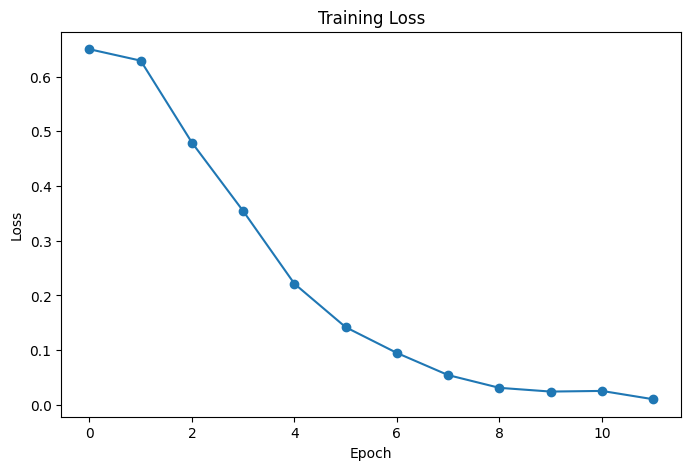

In [14]:
# Plotting training loss

plt.figure(figsize=(8,5))

plt.plot(losses, marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

## Model Evaluation

After training, the model is evaluated using unseen test data.

Evaluation metrics:

- Accuracy
- Classification Report
- Confusion Matrix

In [15]:
# Evaluating model

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for reviews, labels in test_loader:


        outputs = model(reviews)

        preds = (
            outputs >= 0.5
        ).int().cpu().numpy()

        predictions.extend(preds)

        true_labels.extend(labels.numpy())

In [16]:
# Calculating accuracy

accuracy = accuracy_score(
    true_labels,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.7963333333333333


In [17]:
# Generating classification report

print(
    classification_report(
        true_labels,
        predictions,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.75      0.88      0.81      2976
    Positive       0.86      0.71      0.78      3024

    accuracy                           0.80      6000
   macro avg       0.81      0.80      0.80      6000
weighted avg       0.81      0.80      0.79      6000



In [18]:
# Creating confusion matrix

cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[2623  353]
 [ 869 2155]]


## Confusion Matrix

The confusion matrix shows correct and incorrect sentiment predictions made by the model.

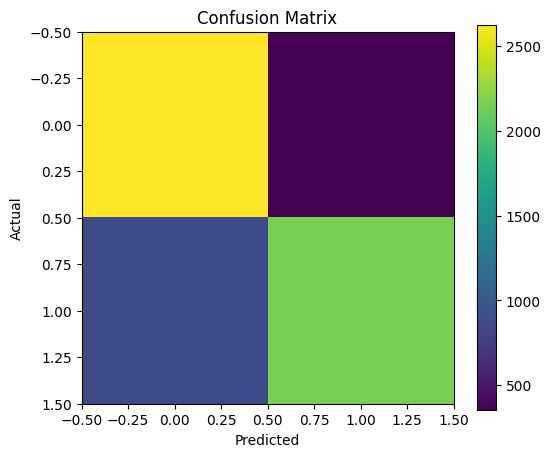

In [19]:
# Plotting confusion matrix

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

## Testing Custom Reviews

The trained model is tested using sample movie reviews to check prediction performance on unseen text.

In [20]:
# Predicting sentiment for custom review

def predict_sentiment(review):

    model.eval()

    encoded = encode_text(review)

    review_tensor = torch.tensor(
        encoded,
        dtype=torch.long
    ).unsqueeze(0)

    with torch.no_grad():
        prediction = model(review_tensor).item()

    if prediction >= 0.5:
        print("Positive Review")
    else:
        print("Negative Review")

    print("Score:", prediction)

In [21]:
# Testing model on sample reviews

predict_sentiment(
    "This movie was amazing and I loved it"
)

predict_sentiment(
    "This movie was boring and very slow"
)

Positive Review
Score: 0.9948000907897949
Negative Review
Score: 0.0013162556570023298


# Conclusion

This project implemented sentiment analysis using PyTorch and a bidirectional LSTM neural network.

The model was trained using the IMDb movie review dataset to classify reviews as either positive or negative sentiment.

The final model achieved approximately **79% accuracy** on the test dataset and was also able to correctly classify custom review examples with high confidence.

This project demonstrates:

- text preprocessing
- tokenization and vocabulary building
- sequence modeling using LSTM
- sentiment classification
- model evaluation using accuracy, classification report, and confusion matrix

Overall, the model successfully learned patterns in movie review text and was able to predict sentiment on unseen reviews.